Task 5 – Model Evaluation, Comparison and Explainability

In [1]:
#Import required libraries for pyspark
from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel
from pyspark.sql.functions import col, when

In [2]:
# Initialising spark session
spark = SparkSession.builder \
    .appName("FraudDetectionTask3") \
    .master("local[2]") \
    .config("spark.driver.memory", "6g") \
    .getOrCreate()
print("Spark session created successfully")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/27 14:31:56 WARN Utils: Your hostname, Sais-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.223.134.171 instead (on interface en0)
26/06/27 14:31:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/27 14:31:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session created successfully


----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 56464)
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/socketserver.py", line 318, in _handle_request_noblock
    self.process_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/socketserver.py", line 349, in process_request
    self.finish_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/socketserver.py", line 362, in finish_request
    self.RequestHandlerClass(request, client_address, self)
    ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/socketserver.py", line 766, in __init__
    self.handle()
    ~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/site-packages/pyspark/accumulators.py", line 303, in handle
    poll(accum_updates)
    ~~~~^^^^^^^^^^^^^^^
  File "/o

In [3]:
# Load processed data
processed_df = spark.read.parquet("task2_processed_data")

In [4]:
# Load pipeline model
pipeline_model = PipelineModel.load("task2_pipeline")

In [5]:
# Check whether processed data is loaded correctly
processed_df.printSchema()
processed_df.show(5)

root
 |-- label: double (nullable = true)
 |-- c1: double (nullable = true)
 |-- c2: double (nullable = true)
 |-- c3: double (nullable = true)
 |-- c4: double (nullable = true)
 |-- c5: double (nullable = true)
 |-- c6: double (nullable = true)
 |-- c7: double (nullable = true)
 |-- c8: double (nullable = true)
 |-- c9: double (nullable = true)
 |-- c10: double (nullable = true)
 |-- c11: double (nullable = true)
 |-- c12: double (nullable = true)
 |-- c13: double (nullable = true)
 |-- c14: double (nullable = true)
 |-- c15: double (nullable = true)
 |-- c16: double (nullable = true)
 |-- c17: double (nullable = true)
 |-- c18: double (nullable = true)
 |-- c19: double (nullable = true)
 |-- c20: double (nullable = true)
 |-- c21: double (nullable = true)
 |-- c22: double (nullable = true)
 |-- c23: double (nullable = true)
 |-- c24: double (nullable = true)
 |-- c25: double (nullable = true)
 |-- c26: double (nullable = true)
 |-- c27: double (nullable = true)
 |-- c28: double (null

26/06/27 14:32:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-----+------------------+-------------------+-------------------+------------------+-------------------+------------------+--------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+--------------------+-------------------+-----------------+-------------------+--------------------+--------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+--------------------+--------------------+
|label|                c1|                 c2|                 c3|                c4|                 c5|                c6|                  c7|                 c8|                c9|               c10|                c11|                c12|               c13|               c14|                 c15|                c16|              c17|                c18|                 c19|                 c20|  

In [6]:
# Split dataset into 70% training and 30% testing
train_data, test_data = processed_df.randomSplit([0.7, 0.3], seed=42)

Load the Saved Models

In [7]:
# Import required libraries
from pyspark.ml.classification import (
    LogisticRegressionModel,
    DecisionTreeClassificationModel,
    RandomForestClassificationModel,
    GBTClassificationModel
)

# Load the models to a new variable
lr_model = LogisticRegressionModel.load("lr_model")
dt_model = DecisionTreeClassificationModel.load("dt_model")
rf_model = RandomForestClassificationModel.load("rf_model")
gbt_model = GBTClassificationModel.load("gbt_model")

print("Saved models loaded successfully")

Saved models loaded successfully


Generate Predictions

In [8]:
lr_predictions = lr_model.transform(test_data)
dt_predictions = dt_model.transform(test_data)
rf_predictions = rf_model.transform(test_data)
gbt_predictions = gbt_model.transform(test_data)

Recreate Evaluators

In [9]:
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

# AUC - measures how well the model separates classes
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

# Accuracy - overall correctness of the prediction
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

# F1 Score - shows how well the model balances correct predictions and missed cases
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# Precision – shows how many of the predicted positive cases are actually correct
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

Compute the Metrics Evaluators

In [10]:
# Logistic Regression Model
lr_accuracy = accuracy_evaluator.evaluate(lr_predictions)
lr_auc = auc_evaluator.evaluate(lr_predictions)
lr_f1 = f1_evaluator.evaluate(lr_predictions)
lr_precision = precision_evaluator.evaluate(lr_predictions)

# Decision Tree Model
dt_accuracy = accuracy_evaluator.evaluate(dt_predictions)
dt_auc = auc_evaluator.evaluate(dt_predictions)
dt_f1 = f1_evaluator.evaluate(dt_predictions)
dt_precision = precision_evaluator.evaluate(dt_predictions)

# Random Forest Model
rf_accuracy = accuracy_evaluator.evaluate(rf_predictions)
rf_auc = auc_evaluator.evaluate(rf_predictions)
rf_f1 = f1_evaluator.evaluate(rf_predictions)
rf_precision = precision_evaluator.evaluate(rf_predictions)

# GBT Model
gbt_accuracy = accuracy_evaluator.evaluate(gbt_predictions)
gbt_auc = auc_evaluator.evaluate(gbt_predictions)
gbt_f1 = f1_evaluator.evaluate(gbt_predictions)
gbt_precision = precision_evaluator.evaluate(gbt_predictions)

26/06/27 14:32:16 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/06/27 14:34:49 WARN DAGScheduler: Broadcasting large task binary with size 1191.2 KiB
26/06/27 14:35:29 WARN DAGScheduler: Broadcasting large task binary with size 1178.2 KiB
26/06/27 14:36:23 WARN DAGScheduler: Broadcasting large task binary with size 1191.2 KiB
26/06/27 14:37:01 WARN DAGScheduler: Broadcasting large task binary with size 1191.2 KiB
                                                                                

Full Metrics Table

In [11]:
# Full metrics comparission table of all the 4 models

import pandas as pd

# Create a list containing evaluation metrics results of all 4 ML models
data = [
    ("Logistic Regression", lr_accuracy, lr_auc, lr_f1, lr_precision),
    ("Decision Tree", dt_accuracy, dt_auc, dt_f1, dt_precision),
    ("Random Forest", rf_accuracy, rf_auc, rf_f1, rf_precision),
    ("GBT Classifier", gbt_accuracy, gbt_auc, gbt_f1, gbt_precision)
]

# Define column names for the summary table
columns = ["Model", "Accuracy", "AUC", "F1 Score", "Precision"]

# Convert the data into a pandas DataFrame and display the table
summary_df = pd.DataFrame(data, columns=columns)
summary_df

,Model,Accuracy,AUC,F1 Score,Precision
0,Logistic Regression,0.635175,0.679042,0.629832,0.635862
1,Decision Tree,0.704703,0.669855,0.704703,0.704703
2,Random Forest,0.697418,0.769556,0.696473,0.697084
3,GBT Classifier,0.718196,0.795335,0.718085,0.718026


Confusion Matrices

In [12]:
# Display confusion matrics of each ML model

# Logistic Regression 
print("Logistic Regression Confusion Matrix")
lr_predictions.groupBy("label","prediction").count().show()

# Decision Tree
print("Decision Tree Confusion Matrix")
dt_predictions.groupBy("label","prediction").count().show()

# Random Forest
print("Random Forest Confusion Matrix")
rf_predictions.groupBy("label","prediction").count().show()

# GBT
print("GBT Confusion Matrix")
gbt_predictions.groupBy("label","prediction").count().show()

Logistic Regression Confusion Matrix


+-----+----------+-------+
|label|prediction|  count|
+-----+----------+-------+
|  1.0|       1.0|1301484|
|  0.0|       1.0| 756512|
|  1.0|       0.0| 448118|
|  0.0|       0.0| 795825|
+-----+----------+-------+

Decision Tree Confusion Matrix


26/06/27 14:48:53 WARN DAGScheduler: Broadcasting large task binary with size 1190.1 KiB


+-----+----------+-------+
|label|prediction|  count|
+-----+----------+-------+
|  1.0|       1.0|1262085|
|  0.0|       1.0| 487536|
|  1.0|       0.0| 487517|
|  0.0|       0.0|1064801|
+-----+----------+-------+

Random Forest Confusion Matrix


26/06/27 14:49:29 WARN DAGScheduler: Broadcasting large task binary with size 1158.3 KiB
                                                                                

+-----+----------+-------+
|label|prediction|  count|
+-----+----------+-------+
|  1.0|       1.0|1305002|
|  0.0|       1.0| 554508|
|  1.0|       0.0| 444600|
|  0.0|       0.0| 997829|
+-----+----------+-------+

GBT Confusion Matrix


[Stage 102:===================================================>   (34 + 2) / 36]

+-----+----------+-------+
|label|prediction|  count|
+-----+----------+-------+
|  1.0|       1.0|1294156|
|  0.0|       1.0| 475055|
|  1.0|       0.0| 455446|
|  0.0|       0.0|1077282|
+-----+----------+-------+



ROC Curve

In [13]:
# Import libraries to plot ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [14]:
# Creating a helper function to plot ROC Curve

def plot_roc_curve(predictions, model_name):
    # Convert spark to pandas
    pdf = predictions.select("label", "probability").toPandas() 
    
    y_true = pdf["label"]
    y_score = pdf["probability"].apply(lambda x: x[1])

    # Calculate False positive rate and True positive rate
    fpr, tpr, _ = roc_curve(y_true, y_score)

    # Calculate Area Under the Curve
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for the model
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {roc_auc:.3f}")

26/06/27 14:53:38 WARN DAGScheduler: Broadcasting large task binary with size 1174.6 KiB
                                                                                

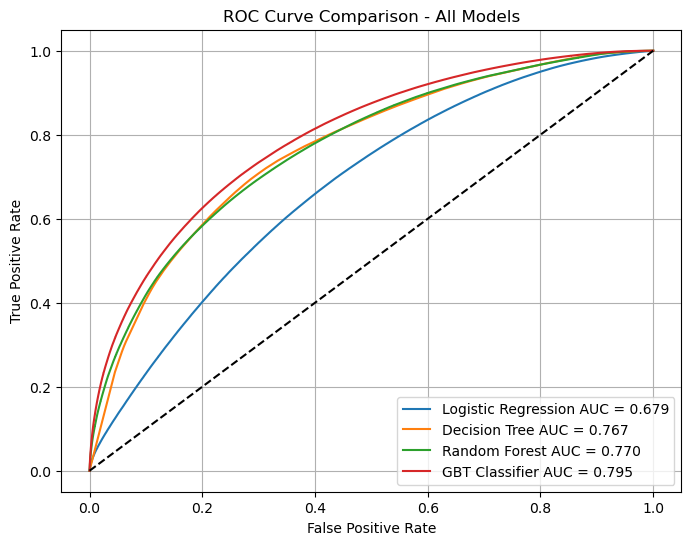

In [15]:
plt.figure(figsize=(8,6))

# Plot ROC for the 4 ML models
plot_roc_curve(lr_predictions, "Logistic Regression")
plot_roc_curve(dt_predictions, "Decision Tree")
plot_roc_curve(rf_predictions, "Random Forest")
plot_roc_curve(gbt_predictions, "GBT Classifier")

# Plot diagonal Reference line representing a random classifier
plt.plot([0, 1], [0, 1], 'k--')
R
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All Models")

plt.legend()
plt.grid(True)

plt.show()

Precision-Recall (PR) Curve 

In [16]:
# Import libraries for PR Curve
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

In [17]:
# Creating helper function to plot PR Curve

def plot_pr_curve(predictions, model_name):
    pdf = predictions.select("label", "probability").toPandas()

    y_true = pdf["label"]
    y_score = pdf["probability"].apply(lambda x: x[1])

    # Calculate precision and recall values
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    # Calculate AUC 
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f"{model_name} AUC = {pr_auc:.3f}")

26/06/27 15:15:34 WARN DAGScheduler: Broadcasting large task binary with size 1174.6 KiB
                                                                                

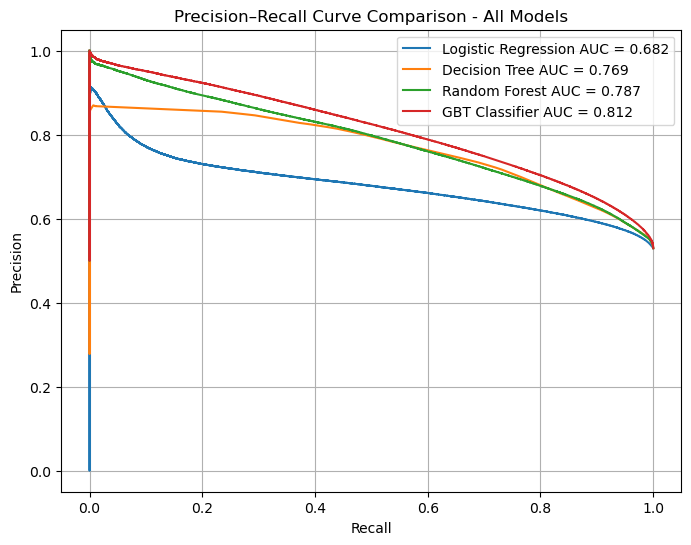

In [18]:
plt.figure(figsize=(8,6))

# Plot PR Curve for the 4 ML moodels
plot_pr_curve(lr_predictions, "Logistic Regression")
plot_pr_curve(dt_predictions, "Decision Tree")
plot_pr_curve(rf_predictions, "Random Forest")
plot_pr_curve(gbt_predictions, "GBT Classifier")

# Graph settings
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison - All Models")
plt.legend()
plt.grid(True)

plt.show()

Perturbation Analysis 

In [25]:
# Create a perturbed version of test data with 80% training and 20% testing
perturbed_test = test_data.sample(fraction=0.8, seed=123)

In [26]:
# Train and Evaluate the models again using new test data

# Logistic Regression
lr_pred_p = lr_model.transform(perturbed_test)
lr_auc_p = auc_evaluator.evaluate(lr_pred_p)
lr_f1_p = f1_evaluator.evaluate(lr_pred_p)

# Decision Tree
dt_pred_p = dt_model.transform(perturbed_test)
dt_auc_p = auc_evaluator.evaluate(dt_pred_p)
dt_f1_p = f1_evaluator.evaluate(dt_pred_p)

# Random Forest
rf_pred_p = rf_model.transform(perturbed_test)
rf_auc_p = auc_evaluator.evaluate(rf_pred_p)
rf_f1_p = f1_evaluator.evaluate(rf_pred_p)

# GBT
gbt_pred_p = gbt_model.transform(perturbed_test)
gbt_auc_p = auc_evaluator.evaluate(gbt_pred_p)
gbt_f1_p = f1_evaluator.evaluate(gbt_pred_p)

26/06/27 17:59:29 WARN DAGScheduler: Broadcasting large task binary with size 1181.6 KiB
26/06/27 18:00:14 WARN DAGScheduler: Broadcasting large task binary with size 1194.6 KiB
                                                                                

In [29]:
# Compare Stability by creating a comparission table

stability_results = [
    ("Logistic Regression",
     lr_auc, lr_auc_p, abs(lr_auc - lr_auc_p),
     lr_f1, lr_f1_p, abs(lr_f1 - lr_f1_p)),

    ("Decision Tree",
     dt_auc, dt_auc_p, abs(dt_auc - dt_auc_p),
     dt_f1, dt_f1_p, abs(dt_f1 - dt_f1_p)),

    ("Random Forest",
     rf_auc, rf_auc_p, abs(rf_auc - rf_auc_p),
     rf_f1, rf_f1_p, abs(rf_f1 - rf_f1_p)),

    ("GBT Classifier",
     gbt_auc, gbt_auc_p, abs(gbt_auc - gbt_auc_p),
     gbt_f1, gbt_f1_p, abs(gbt_f1 - gbt_f1_p))
]

# Model Name, AUC comparison, F1 comparison, Difference in values
columns = [
    "Model",
    "Original AUC", "New AUC", "AUC Difference",
    "Original F1", "New F1", "F1 Difference"
]

# Convert results into a DataFrame and display
stability_df = pd.DataFrame(stability_results, columns=columns)
stability_df

,Model,Original AUC,New AUC,AUC Difference,Original F1,New F1,F1 Difference
0,Logistic Regression,0.679042,0.678843,0.000198,0.629832,0.629818,0.000013
1,Decision Tree,0.669855,0.669701,0.000154,0.704703,0.704526,0.000177
2,Random Forest,0.769556,0.769429,0.000127,0.696473,0.696384,0.000089
3,GBT Classifier,0.795335,0.795253,0.000082,0.718085,0.717996,0.000089


Perturbation Analysis Conclusion

A second train-test split (80/20) with a different random seed was used to test all 4 models stability. The performance of all four models was compared using AUC, F1 Score and difference e between them. Small variations in performance indicate that the models are stable and generalize well to unseen data.

LIME Explainability

In [30]:
# I chose LIME over SHAP because it is simpler, faster and easy to explain without heavy computation.

In [31]:
# Import required libraries for LIME
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import random

In [32]:
# Convert part of Spark DataFrame to Pandas since LIME cannot handle huge data
sample_df = processed_df.select("scaledfeatures").limit(1000).toPandas()

# Convert Spark vector to NumPy array
X = np.array([x.toArray() for x in sample_df["scaledfeatures"]])

In [33]:
# Initialize LIME explainer for tabular data

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    # Reference data used by LIME to understand feature patterns in the dataset
    training_data = X,

    # Specifies this is a classification model
    mode="classification",

    # Name of input features and output class
    feature_names=[f"c{i}" for i in range(1, 29)],
    class_names=["0", "1"],

    #Converts continuos values to bins so its easy to interpret
    discretize_continuous=True
)

In [34]:
# Pick one sample to explain
i = random.randint(0, len(X)-1)
instance = X[i]

In [35]:
# Function required by LIME to get probablities

def predict_fn(x):
    # Convert to LIME input to Spark format required by ML model
    from pyspark.ml.linalg import Vectors
    spark_df = spark.createDataFrame([
        (Vectors.dense(row),) for row in x
    ], ["scaledfeatures"])

    # Generate predictions using trained Random Forest model
    preds = rf_model.transform(spark_df)

    # Extract proabablities of each class and convert to numpy array
    return np.array(
        preds.select("probability").rdd.map(lambda r: r[0].toArray()).collect()
    )

In [1]:
# I chose Random Forest model for LIME Explanation out of 4 ML modes I trained

In [40]:
# Generate LIME explanation for selected instance

exp = lime_explainer.explain_instance(
    # Function that returns model prediction probabilities
    instance,
    predict_fn,

    # Number of top 10 important features to display in explanation
    num_features=10
)

lime_results = exp.as_list()

# Display in table format for cleaner look
df_lime = pd.DataFrame(lime_results, columns=["Feature Condition", "Impact"])
df_lime

26/06/27 20:35:00 WARN DAGScheduler: Broadcasting large task binary with size 1133.2 KiB
                                                                                

,Feature Condition,Impact
0,2.47 < c28 <= 2.79,0.073237
1,c23 > 2.81,0.063492
2,c6 > 2.48,0.047738
3,2.60 < c27 <= 3.10,0.037314
4,c4 > 2.12,-0.026689
5,c18 > 2.44,0.015117
6,1.10 < c1 <= 1.58,0.015107
7,-0.01 < c2 <= 0.71,-0.007723
8,c20 <= -0.88,0.006892
9,1.17 < c22 <= 1.32,-0.006710


Model Explainability using LIME

LIME was used to explain individual predictions of the Random Forest model. It shows which features contributed positively or negatively to a specific prediction. The results indicate that only a few features have strong impact on the model output, despite the model being complex.